<div align="center">

# <span style="color: #3498db;">CA2 - Genetic & Game</span>

**<span style="color:rgb(247, 169, 0);">Majid Sadeghinejad</span> - <span style="color:rgb(143, 95, 195);">810101459</span>**

</div>


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

# 📊 Matplotlib – Data Visualization in Python  

matplotlib is a python library that is mainly used for data visualization. This library allows you to plot different type of figures including scatters and histograms. In the first part of this project you are supposed to implement a genetic algorithm. To visualize plots that are required in the project description use plotting as much as you can because it gives a great insight on what is happening during each run. It also helps you to compare your results whenevever you want to understand effect of different parameters during different runs.
For more information, check [this notebook](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.00-Introduction-To-Matplotlib.ipynb) and visit [the website](https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py).

In [51]:
import matplotlib.pyplot as plt

# <span style="color: #3498db;">Genetic Algorithm</span>

In [52]:
import numpy as np

In [53]:
# These functions are given as samples to use in the algorithm
def getTargetFunction(functionName="sin_cos"):
    def sinCosFunction(t):
        """Target function: sin(2πt) + 0.5*cos(4πt)."""
        return np.sin(2 * np.pi * t) + 0.5 * np.cos(4 * np.pi * t)

    def linearFunction(t):
        """Simple linear function: y = 2t + 1."""
        return 2 * t + 1

    def quadraticFunction(t):
        """Quadratic function: y = 4t^2 - 4t + 2."""
        return 4 * (t**2) - 4 * t + 2

    def cubicFunction(t):
        """Cubic function: y = 8t^3 - 12t^2 + 6t."""
        return 8 * (t**3) - 12 * (t**2) + 6 * t

    def gaussianFunction(t):
        """Gaussian function centered at t=0.5."""
        mu = 0.5
        sigma = 0.1  # Adjust sigma to control the width of the peak
        return np.exp(-((t - mu) ** 2) / (2 * sigma**2))

    def squareWaveFunction(t):
        """Approximation of a square wave. Smoothed for better Fourier approximation."""
        return 0.5 * (np.sign(np.sin(2 * np.pi * t)) + 1)

    def sawtoothFunction(t):
        """Sawtooth wave, normalized to [0, 1]."""
        return (t * 5) % 1

    def complexFourierFunction(t):
        return (
            np.sin(2 * np.pi * t)
            + 0.3 * np.cos(4 * np.pi * t)
            + 0.2 * np.sin(6 * np.pi * t)
            + 0.1 * np.cos(8 * np.pi * t)
        )

    def polynomialFunction(t):
        return 10 * (t**5) - 20 * (t**4) + 15 * (t**3) - 4 * (t**2) + t + 0.5

    functionOptions = {
        "sin_cos": sinCosFunction,
        "linear": linearFunction,
        "quadratic": quadraticFunction,
        "cubic": cubicFunction,
        "gaussian": gaussianFunction,
        "square_wave": squareWaveFunction,
        "sawtooth": sawtoothFunction,
        "complex_fourier": complexFourierFunction,
        "polynomial": polynomialFunction,
    }

    selectedFunction = functionOptions.get(functionName.lower())
    if selectedFunction:
        return selectedFunction

<div style="color:rgb(235, 66, 32); font-weight: bold;">⚠️ Important Note:</div>  

Using **NumPy arrays** allows you to perform operations on vectors **more efficiently** and **faster**.

**Avoid using `for` loops** whenever possible, as vectorized operations in NumPy are **optimized for performance** and significantly reduce execution time.  


## Part 1: Defining
As we are looking for fourier series coeffs we consider our chromosome as below and each coefficient is a gene:

[a0, a1, b1, a2, b2, ..., an, bn]

in this project our n is 20 but by increasing n we can get better result.


In [54]:
# algorithm parameters
numHarmonics = 20
numCoeffs = numHarmonics * 2 + 1
generations = 1000
mutationRate = 0.01
functionRange = (-np.pi, np.pi)
sampleCount = 100

In [55]:
# generate samples
tSamples = np.linspace(functionRange[0], functionRange[1], sampleCount)
fSamples = getTargetFunction("linear")(tSamples)

In [63]:
n = np.arange(1, numHarmonics + 1)
cos_matrix = np.cos(np.outer(n, tSamples))
sin_matrix = np.sin(np.outer(n, tSamples))

def calculate_fouriers(population):
    a0 = population[:, 0]
    a_n = population[:, 1::2]  
    b_n = population[:, 2::2]
    return a0[:, None] / 2 + a_n.dot(cos_matrix) + b_n.dot(sin_matrix)

def calculate_fitness_RMSE(population):
    fCalculateds = calculate_fouriers(population)
    return np.sqrt(np.mean((fSamples - fCalculateds)**2, axis=1))

def calculate_fitness_MAE(population):
    fCalculateds = calculate_fouriers(population)
    mae = np.mean(np.abs(fSamples - fCalculateds), axis=1)
    return mae

def calculate_fitness_MaeRel(population):
    fCalculateds = calculate_fouriers(population)
    relative_error = np.abs((fSamples - fCalculateds) / np.maximum(np.abs(fSamples), 1e-8))
    mae_relative = np.mean(relative_error, axis=1)
    return mae_relative

def tournament_selection(fitness, tournament_size=3):
    populationSize = fitness.shape[0]
    tournaments = np.random.randint(0, populationSize, size=(int(populationSize/2), tournament_size))
    tournament_fitness = fitness[tournaments]
    return tournaments[np.arange(int(populationSize/2)), np.argmin(tournament_fitness, axis=1)]

def onePoint_crossover(p1, p2, forward_rate=0.1):
    parents_size = p1.shape[0]
    cp = np.random.randint(1, numCoeffs, size=parents_size)
    indices = np.arange(numCoeffs)
    mask = indices[None, :] < cp[:, None]
    child1 = np.where(mask, p1, p2)
    child2 = np.where(mask, p2, p1)
    
    forward_mask = np.random.rand(parents_size) < forward_rate
    forward_mask = forward_mask[:, None]
    child1 = np.where(forward_mask, p1, child1)
    child2 = np.where(forward_mask, p2, child2)
    
    return child1, child2

def twoPoint_crossover(p1, p2):
    parents_size = p1.shape[0]
    cp1 = np.random.randint(1, numCoeffs - 1, size=parents_size)
    cp2 = np.array([np.random.randint(c+1, numCoeffs) for c in cp1])
    
    indices = np.arange(numCoeffs)
    mask = (indices[None, :] >= cp1[:, None]) & (indices[None, :] < cp2[:, None])
    
    child1 = p1.copy()
    child2 = p2.copy()
    
    child1[mask] = p2[mask]
    child2[mask] = p1[mask]
    
    return child1, child2

def uniform_crossover(p1, p2, swap_prob=0.5):
    parents_size = p1.shape[0]
    mask = np.random.rand(parents_size, numCoeffs) < swap_prob
    child1 = np.where(mask, p2, p1)
    child2 = np.where(mask, p1, p2)
    
    return child1, child2

def ranking_selection(fitness):
    populationSize = fitness.shape[0]
    num_parents = int(populationSize / 2)
    sorted_indices = np.argsort(fitness)
    ranks = np.empty_like(sorted_indices)
    ranks[sorted_indices] = np.arange(1, populationSize + 1)
    
    probs = ranks / np.sum(ranks)
    selected_indices = np.random.choice(populationSize, size=num_parents, replace=True, p=probs)
    
    return selected_indices

def roulette_wheel_selection(fitness):
    populationSize = fitness.shape[0]
    num_parents = int(populationSize / 2)
    epsilon = 1e-8
    fitness_scores = 1.0 / (fitness + epsilon)
    probs = fitness_scores / np.sum(fitness_scores)
    selected_indices = np.random.choice(populationSize, size=num_parents, replace=True, p=probs)
    
    return selected_indices

def mutation(population):
    mutation_mask = np.random.rand(*population.shape) < mutationRate
    mutation_noise = np.random.normal(0, 0.5, population.shape)
    return population + mutation_mask * mutation_noise

def calculate_fourier(coeffs):
    a_n = coeffs[1::2]
    b_n = coeffs[2::2]
    return coeffs[0] / 2 + a_n.dot(cos_matrix) + b_n.dot(sin_matrix)

def plot_results(results):
    colors = ['orange', 'green', 'red', 'blue', 'purple']
    plt.figure(figsize=(5, 3))
    plt.plot(tSamples, fSamples, label='Function', color='black', linewidth= 2)
    for i in range(len(results)):
        plt.plot(tSamples, results[i], label=f'option {i+1}', color= colors[i], linestyle='--')
    plt.title("Genetic Algorithm")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [61]:
def genetic_fourier(populationSize=100, evaluationFunc=calculate_fitness_RMSE, selectionFunc=tournament_selection, crossoverFunc=onePoint_crossover):
    population = np.random.uniform(-2, 2, (populationSize, numCoeffs))
    best_individual = None
    best_fitness = np.inf
    best_history = []
    
    for generation in range(generations):
        fitness = evaluationFunc(population)
        best_index = np.argmin(fitness)
        best = fitness[best_index]
        best_history.append(best)
        
        if best < best_fitness:
            best_fitness = best
            best_individual = population[best_index].copy()
            
        p1 = population[selectionFunc(fitness)]
        p2 = population[selectionFunc(fitness)]
        
        child1, child2 = crossoverFunc(p1, p2)
        new_population = np.vstack([child1, child2])
        population = mutation(new_population)
    
    print(f"Population: {populationSize}, Evaluation: {evaluationFunc.__name__}")
    print(f"Final best evaluation: {best_fitness:.6f}\n")
    return best_individual, best_history

## Part 2: Population

As you can see here we tested 3 different population size, small (which doesn't give an acceptable result, but it get the form of function), meduim (which is enough we get the form of function but it isn't fit completely), large (now we nearly fitted the model to function) and extra large (there is no significant difference between this size and large size, showing that from somewhere it isn't reasonable to increase the size)

so we can see increasing the population size will cause more precision but affect badly on time and number of processes

also when we select the range that initial population is selected from, we affect the generation needs to fit the model to function and also the mutation rate cause we need lots of mutations !

Population: 10, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.947113

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942618

Population: 1000, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942575

Population: 5000, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942574



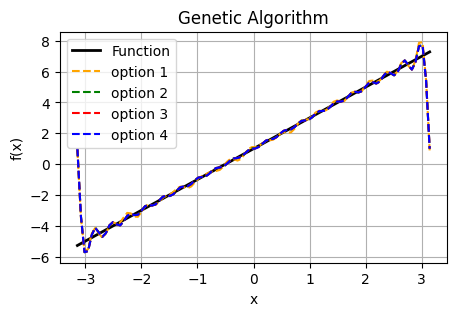

In [116]:
options = [10, 100, 1000, 5000]
results = [calculate_fourier(genetic_fourier(populationSize = option)[0]) for option in options]
plot_results(results)

## Part 3: Evaluation

here we used three evaluation method first one is fimiliar RMSE method and the best one by the way is it , second one is MAE that instead of power of 2 use the absloute of differences and the third one is MaeRel that uses absloute value but it takes kind of avarge of differences

as you can see the MaeRel is the worst option it has a good estimate of its self but it can't show the real difference of target and model in a way that genetic algorithm needs

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942656

Population: 100, Evaluation: calculate_fitness_MAE
Final best evaluation: 0.288357

Population: 100, Evaluation: calculate_fitness_MaeRel
Final best evaluation: 0.769907



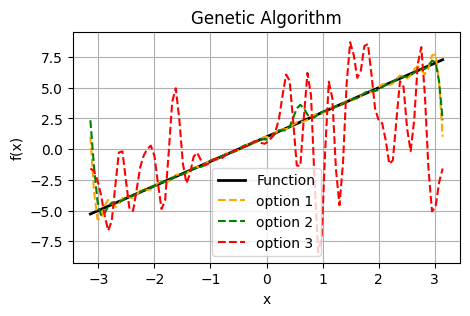

In [104]:
options = [calculate_fitness_RMSE, calculate_fitness_MAE, calculate_fitness_MaeRel]
results = [calculate_fourier(genetic_fourier(evaluationFunc = option)[0]) for option in options]
plot_results(results)

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 5.278483

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 1.213287

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942619



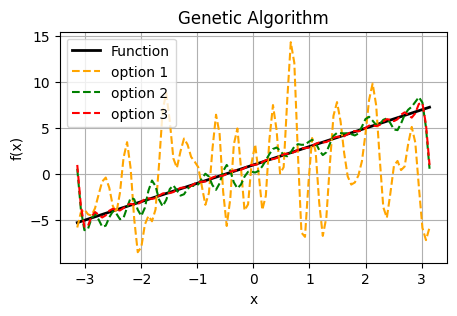

In [71]:
options = [ranking_selection, roulette_wheel_selection, tournament_selection]
results = [calculate_fourier(genetic_fourier(selectionFunc = option)[0]) for option in options]
plot_results(results)

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942614

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942644

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942621



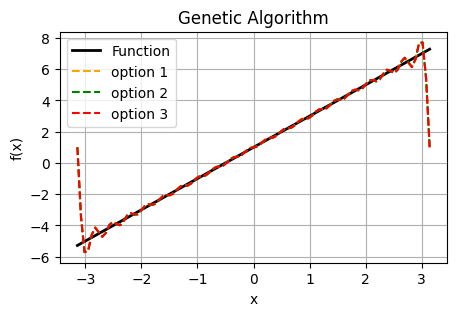

In [72]:
options = [onePoint_crossover, twoPoint_crossover, uniform_crossover]
results = [calculate_fourier(genetic_fourier(crossoverFunc = option)[0]) for option in options]
plot_results(results)

## Part 4: Crossover & Mutation

you can see these two algorithm in defining part code for cross over i used single random point crossover which works very well and also we have a parameter which is forward rate that shows the rate of parnents that do not need cross over and will go to next generation directly

also for mutation we have a rate that shows the rate of genes (coeffs) that is changed in the population in each genration the mutation rate is so important and it is connected with the intial population values if the values are near to real values we don't need that much mutation so it's better to set the rate to a small val but if we don't know the proper intial values it is better to set it high

so you can set these parameters in the function arguments

## Part 5: Results

here I draw the plots that asked in description and you can see the results of explaination of pervious parts

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.122603



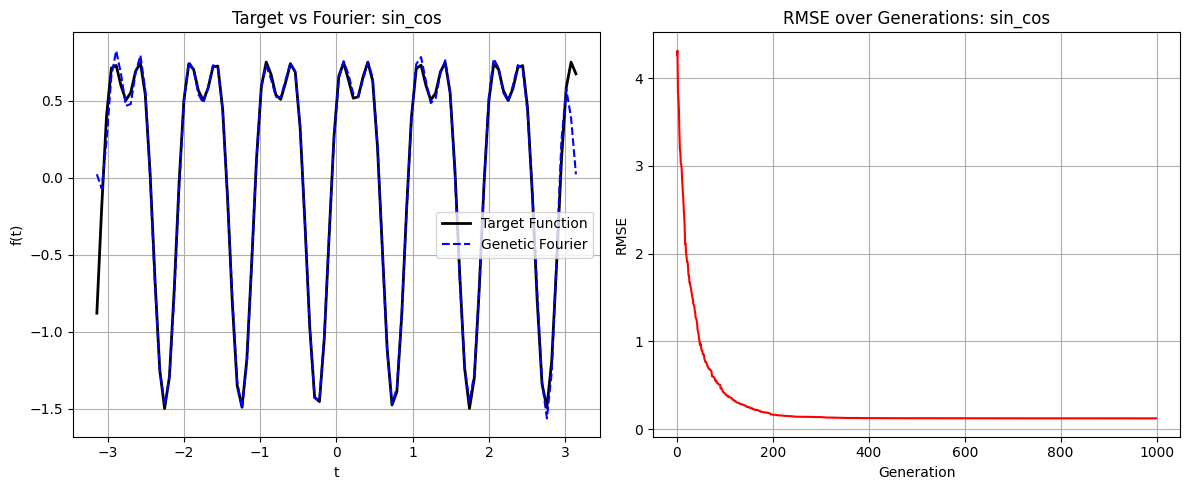

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 1.888265



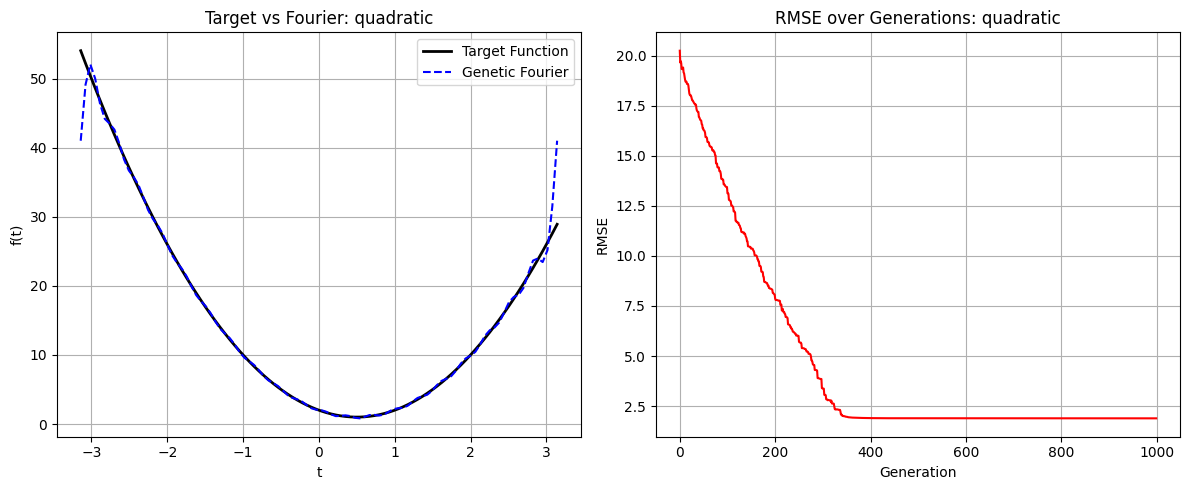

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 46.839402



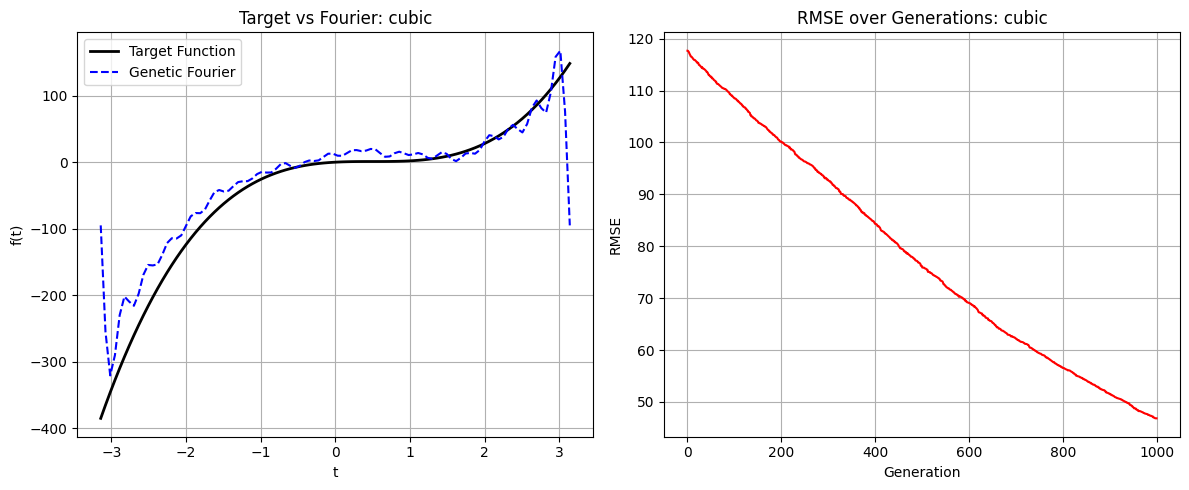

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.014031



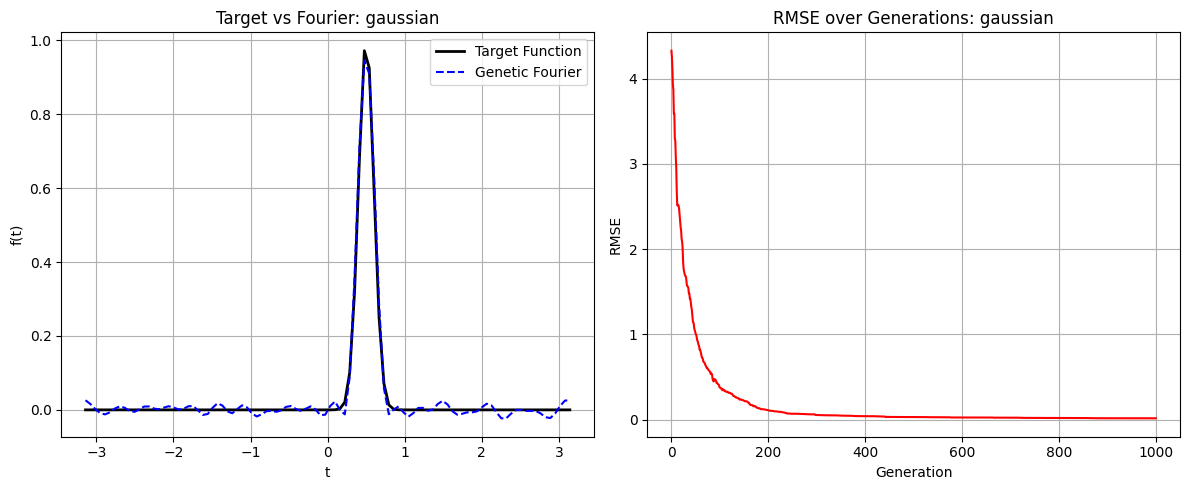

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.160051



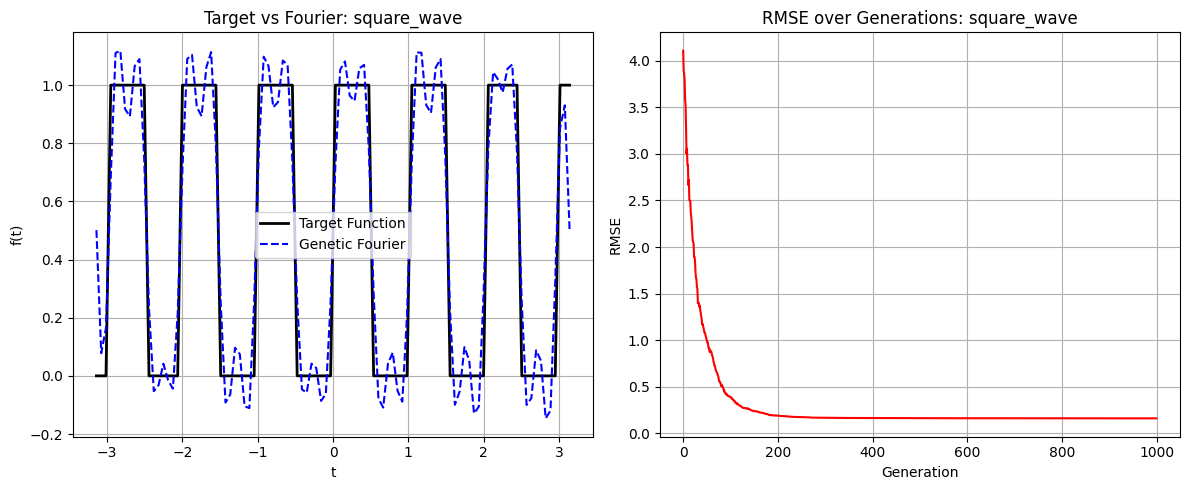

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.268165



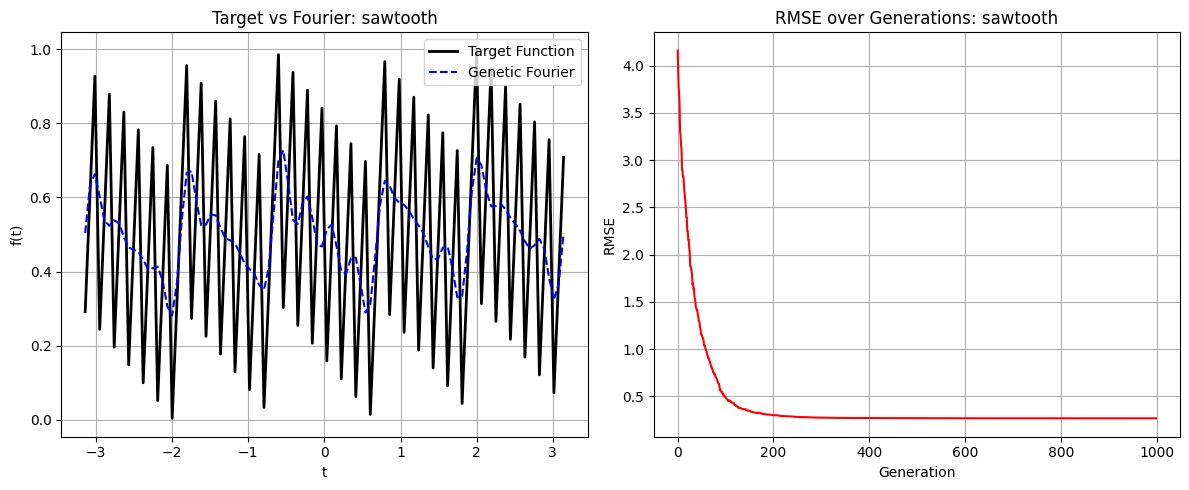

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.155907



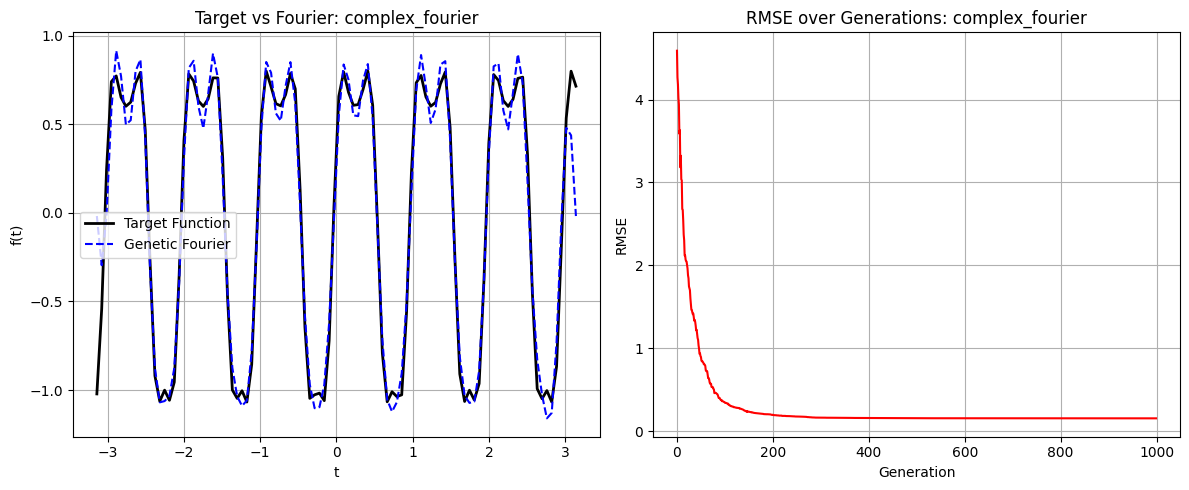

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 1251.951798



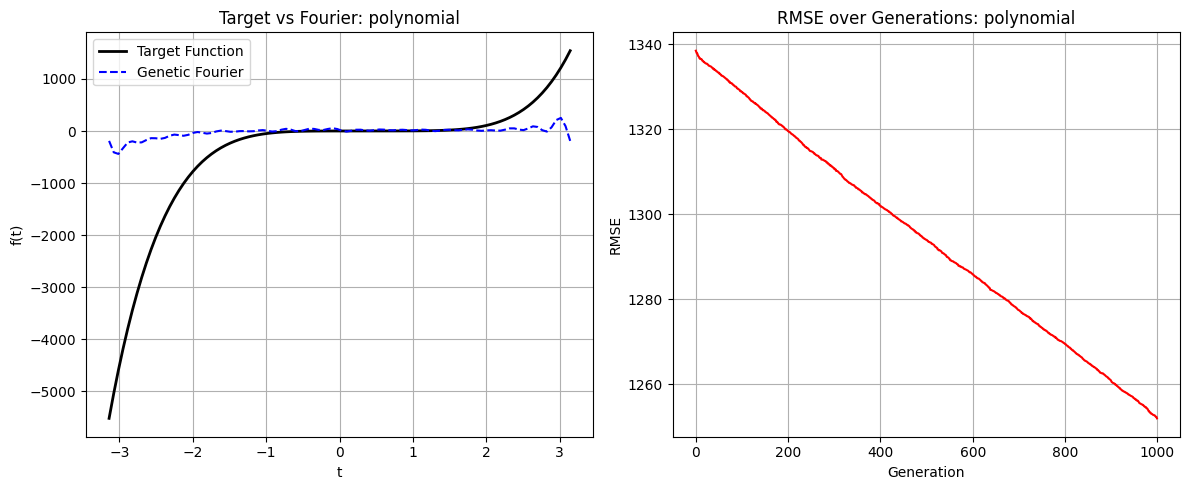

Population: 100, Evaluation: calculate_fitness_RMSE
Final best evaluation: 0.942624



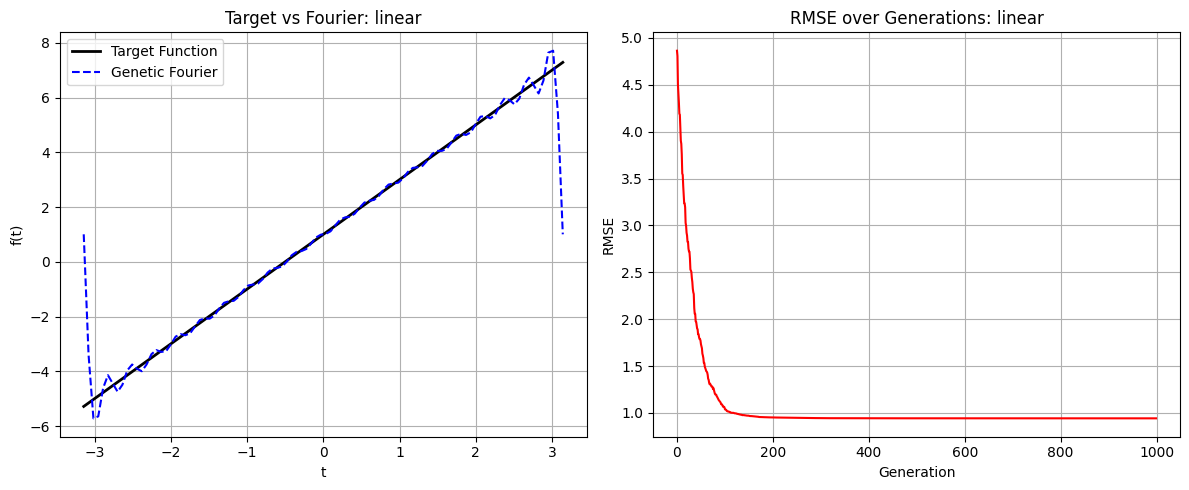

In [105]:
target_functions = [
    "sin_cos", "quadratic", "cubic", 
    "gaussian", "square_wave", "sawtooth", "complex_fourier", "polynomial", "linear"
]

for func_name in target_functions:
    target_func = getTargetFunction(func_name)
    fSamples = target_func(tSamples)
    best_individual, rmse_history = genetic_fourier()
    best_fourier = calculate_fourier(best_individual)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(tSamples, fSamples, label="Target Function", color="black", linewidth=2)
    plt.plot(tSamples, best_fourier, label="Genetic Fourier", linestyle="--", color="blue")
    plt.title(f"Target vs Fourier: {func_name}")
    plt.xlabel("t")
    plt.ylabel("f(t)")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(generations), rmse_history, color="red")
    plt.title(f"RMSE over Generations: {func_name}")
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

## Questions

1. 
   In this project, chromosomes are Fourier series coefficients like `[a0, a1, b1, a2, b2, ..., an, bn]`. The number of coefficients is `numCoeffs = 2 * numHarmonics + 1`. Since each gene is initialized in the range `[-2, 2]`, the state space is:  
   State space = (-2 to 2)^(41)
   because the coefficients are continuous values we can't say a discrete number.
   also we have mutations and we can't say a genral number for this question but the current number is the initial state space

2. 
   `Using tournament selection`: This method picks better individuals more often, which helps the algorithm converge faster and `Lowering mutation rate:` If mutation rate is too high, the algorithm might just wander randomly instead of converging. Lowering it helps focus on improving solutions.


3. 
    `Tournament selection`: Randomly pick a few individuals, and the best one among them goes to the next generation. It balances exploration and exploitation. `Rank selection`: Rank individuals by fitness, and the chance of selection depends on their rank. This avoids overly strong individuals dominating the population.

4. 
   `Increase mutation rate:` Higher mutation rate creates more diversity in genes, which helps avoid getting stuck in local optima. `Forward individuals from last generation`: Keep the best individuals for the next generation, but let the rest mutate and crossover to maintain diversity.


5.
   R-squared shows how well the model explains the variance in the target data. The formula is:  
   ```
   (R^2) = 1 - (SS_res / SS_tot)
   ```
   Where `SS_res` is Sum of squared errors (difference between actual and predicted values) and `SS_tot`: Total sum of squares (difference between actual values and their mean).  
   It’s useful here because it tells how well the Fourier series fits the target function. If R² is close to 1, the fit is good.

# <span style="color: #3498db;">Minmax Algorithm</span>

In [3]:
import random
import numpy as np
from math import inf
import time
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.12.1)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
class PentagoGame:
    def __init__(self, ui=False, print=False, depth=2, purning= False):
        self.board = np.zeros((6, 6), dtype=int)
        self.current_player = 1
        self.ui = ui
        self.depth = depth
        self.nodes_visited = 0
        self.game_over = False
        self.result = None
        self.selected_block = None
        self.move_stage = 0  # 0: place piece, 1: select block, 2: rotate
        self.temp_piece = None
        self.print = print
        self.purning = purning
        self.total_nodes = 0
        self.total_time = 0

        if ui:
            pygame.font.init()
            self.screen = pygame.display.set_mode((800, 600))
            pygame.display.set_caption("Pygame Board")
            self.font_large = pygame.font.Font(None, 48)  
            self.font_small = pygame.font.Font(None, 24)
            self.font = pygame.font.SysFont("Arial", 20)
            self.show_buttons = False
            self.buttons = {
                "rotate_cw": pygame.Rect(650, 200, 100, 50),
                "rotate_ccw": pygame.Rect(650, 300, 100, 50),
            }
            self.setup_controls()
            self.draw_board()

    def setup_controls(self):
        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])   # Light Green
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])  # Light Blue

            self.screen.draw_text("CLOCKWISE", self.buttons["rotate_cw"].center)
            self.screen.draw_text("COUNTER-CLOCKWISE", self.buttons["rotate_ccw"].center)


    def hide_rotation_buttons(self):
        self.show_buttons = False

    def show_rotation_buttons(self):
        self.show_buttons = True

    def copy_board(self, board):
        return np.copy(board)

    def rotate_block(self, board, block, direction):
        row_start = (block // 2) * 3
        col_start = (block % 2) * 3
        sub = board[row_start : row_start + 3, col_start : col_start + 3]
        rotated = np.rot90(sub, 3 if direction == "cw" else 1)
        board[row_start : row_start + 3, col_start : col_start + 3] = rotated

    def get_possible_moves(self, board, player):
        moves = []
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    for block in range(4):
                        for dir in ["cw", "ccw"]:
                            moves.append((i, j, block, dir))
        return moves

    def apply_move(self, board, move, player):
        new_board = self.copy_board(board)
        row, col, block, direction = move
        if new_board[row][col] != 0:
            return None
        new_board[row][col] = player
        self.rotate_block(new_board, block, direction)
        return new_board

    def check_winner(self, board):
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    continue

                # Horizontal
                if j <= 1 and np.all(board[i, j : j + 5] == board[i][j]):
                    return board[i][j]

                # Vertical
                if i <= 1 and np.all(board[i : i + 5, j] == board[i][j]):
                    return board[i][j]

                # Diagonal
                if (
                    i <= 1
                    and j <= 1
                    and all(board[i + k][j + k] == board[i][j] for k in range(5))
                ):
                    return board[i][j]

                # Anti-diagonal
                if (
                    i <= 1
                    and j >= 4
                    and all(board[i + k][j - k] == board[i][j] for k in range(5))
                ):
                    return board[i][j]
        if np.all(board != 0):
            return 0
        return None

    def heuristic(self, board):
        weight_matrix = np.array([
            [2, 3, 4, 4, 3, 2],
            [3, 4, 5, 5, 4, 3],
            [4, 5, 6, 6, 5, 4],
            [4, 5, 6, 6, 5, 4],
            [3, 4, 5, 5, 4, 3],
            [2, 3, 4, 4, 3, 2]
        ])

        computer_weight = np.sum(weight_matrix[board == -1])
        human_weight = np.sum(weight_matrix[board == 1])
        computer_count = np.sum(board == -1)
        human_count = np.sum(board == 1)
        count_diff = computer_count - human_count
        return (computer_weight - human_weight) + 10 * count_diff

    def minimax(self, board, depth, maximizingPlayer, alpha, beta):
        if self.game_over:
            return 0

        self.nodes_visited += 1
        self.total_nodes += 1

        winner = self.check_winner(board)
        if winner is not None:
            if winner == -1:
                return 1000 + depth
            elif winner == 1:
                return -1000 - depth
            else:
                return 0

        if depth == 0:
            return self.heuristic(board)

        player = -1 if maximizingPlayer else 1
        moves = self.get_possible_moves(board, player)
        if not moves:
            return 0

        if self.purning:
            ordered_moves = []
            for move in moves:
                new_board = self.apply_move(board, move, player)
                if new_board is None:
                    continue
                h = self.heuristic(new_board)
                ordered_moves.append((h, move, new_board))
            if maximizingPlayer:
                ordered_moves.sort(key=lambda x: x[0], reverse=True)
            else:
                ordered_moves.sort(key=lambda x: x[0])
            moves_data = ordered_moves
        else:
            moves_data = []
            for move in moves:
                new_board = self.apply_move(board, move, player)
                if new_board is None:
                    continue
                moves_data.append((None, move, new_board)) 

        if maximizingPlayer:
            maxEval = -float('inf')
            for _, move, new_board in moves_data:
                eval = self.minimax(new_board, depth - 1, False, alpha, beta)
                maxEval = max(maxEval, eval)
                if self.purning:
                    alpha = max(alpha, eval)
                    if beta <= alpha:
                        break
            return maxEval
        else:
            minEval = float('inf')
            for _, move, new_board in moves_data:
                eval = self.minimax(new_board, depth - 1, True, alpha, beta)
                minEval = min(minEval, eval)
                if self.purning:
                    beta = min(beta, eval)
                    if beta <= alpha:
                        break
            return minEval


    def get_computer_move(self):
        start_time = time.time()
        best_move = None
        best_value = -float('inf')
        moves = self.get_possible_moves(self.board, -1)
        if not moves:
            return None
        
        for move in moves:
            if self.game_over:
                break
            new_board = self.apply_move(self.board, move, -1)
            if new_board is None:
                continue
            value = self.minimax(new_board, self.depth - 1, False, -float('inf'), float('inf'))
            if value > best_value:
                best_value = value
                best_move = move

        move_time = time.time()-start_time
        self.total_time += move_time
        if self.print:
            print(f"Move took {move_time:.2f}s, nodes visited: {self.nodes_visited}")
        self.nodes_visited = 0
        
        return best_move

    def draw_text(self, text, center_pos, max_width):
        font_size = 24
        font = pygame.font.Font(None, font_size)
        text_surface = font.render(text, True, (0, 0, 0))

        text_width = text_surface.get_width()
        if text_width > max_width:
            scale_factor = max_width / text_width
            new_font_size = int(font_size * scale_factor)
            font = pygame.font.Font(None, new_font_size)
            text_surface = font.render(text, True, (0, 0, 0))

        text_rect = text_surface.get_rect(center=center_pos)
        self.screen.blit(text_surface, text_rect)

    def draw_board(self):
        self.screen.fill((0, 0, 0))

        for i in range(6):
            for j in range(6):
                x0 = j * 100
                y0 = i * 100

                if self.board[i][j] == 1:
                    pygame.draw.circle(self.screen, (255, 0, 0), (x0 + 50, y0 + 50), 40)
                elif self.board[i][j] == -1:
                    pygame.draw.circle(self.screen, (0, 0, 255), (x0 + 50, y0 + 50), 40)

                pygame.draw.rect(self.screen, (255, 255, 255), (x0, y0, 100, 100), 1)

        for i in [3, 6]:
            pygame.draw.line(self.screen, (255, 255, 255), (0, i * 100), (600, i * 100), 3)  # Horizontal
            pygame.draw.line(self.screen, (255, 255, 255), (i * 100, 0), (i * 100, 600), 3)  # Vertical

        # Show rotation buttons if in move_stage 2
        if self.move_stage == 2:
            self.highlight_selected_block()
            self.show_rotation_buttons()

        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])  # Light Green
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])  # Light Blue

            self.draw_text(
                "CLOCKWISE",
                self.buttons["rotate_cw"].center,
                self.buttons["rotate_cw"].width,
            )
            self.draw_text(
                "COUNTER-CLOCKWISE",
                self.buttons["rotate_ccw"].center,
                self.buttons["rotate_ccw"].width,
            )

    def click_handler(self, event):
        if self.game_over or self.current_player != 1:
            return

        x, y = event.pos
        if self.move_stage == 0:  # Place piece
            if x > 600:
                return  # clicks on control area
            col = x // 100
            row = y // 100
            if 0 <= row < 6 and 0 <= col < 6 and self.board[row][col] == 0:
                self.temp_piece = (row, col)
                self.board[row][col] = 1
                self.move_stage = 1
                self.draw_board()

        elif self.move_stage == 1:  # Select block
            if x > 600:
                return
            # which block was clicked
            block_x = 0 if x < 300 else 1
            block_y = 0 if y < 300 else 1
            self.selected_block = block_y * 2 + block_x
            self.move_stage = 2
            self.show_rotation_buttons()
            self.highlight_selected_block()

        elif self.move_stage == 2:  # Rotate
            if self.buttons["rotate_cw"].collidepoint(event.pos):
                self.apply_rotation("cw")
            if self.buttons["rotate_ccw"].collidepoint(event.pos):
                self.apply_rotation("ccw")

    def apply_rotation(self, direction):
        self.rotate_block(self.board, self.selected_block, direction)
        self.current_player = -1
        self.move_stage = 0
        self.selected_block = None
        self.temp_piece = None
        self.hide_rotation_buttons()
        self.draw_board()
        pygame.display.flip()
        self.check_game_over()
        pygame.time.delay(1000)
        self.play_computer_move()

    def highlight_selected_block(self):
        colors = [
            (255, 153, 153),
            (153, 255, 153),
            (153, 153, 255),
            (255, 255, 153),
        ]  # RGB colors

        row_start = (self.selected_block // 2) * 3
        col_start = (self.selected_block % 2) * 3

        pygame.draw.rect(
            self.screen,
            colors[self.selected_block],
            (col_start * 100, row_start * 100, 300, 300),
            5,
        )

    def play_computer_move(self):
        move = self.get_computer_move()
        if move and not self.game_over:
            new_board = self.apply_move(self.board, move, -1)
            if new_board is not None:
                self.board = new_board
                self.current_player = 1
                self.draw_board()
                pygame.display.flip()
                self.check_game_over()
            else:
                print("Invalid computer move!")

    def check_game_over(self):
        winner = self.check_winner(self.board)
        if winner is not None:
            self.game_over = True
            self.result = winner
            print("Game over! Result:", winner)
            if self.ui:
                self.show_game_over_message()

    def show_game_over_message(self):
        self.screen.fill((200, 200, 200))
        pygame.draw.rect(self.screen, (255, 255, 255), (100, 200, 500, 200))
        pygame.draw.rect(self.screen, (0, 0, 0), (100, 200, 500, 200), 3)

        result_text = f"Player {self.result} wins!" if self.result != 0 else "Draw!"
        text_surface = self.font_large.render(result_text, True, (255, 0, 0))
        self.screen.blit(text_surface, (250, 250))

        exit_text = self.font_small.render("Click anywhere to exit", True, (0, 0, 0))
        self.screen.blit(exit_text, (230, 350))
        pygame.display.flip()

    def play(self):
        if self.ui:
            running = True
            while running:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                    elif event.type == pygame.MOUSEBUTTONDOWN:
                        self.click_handler(event)
                self.draw_board()
                pygame.display.flip()
            pygame.quit()
            return self.result
        else:
            while not self.game_over:
                winner = self.check_winner(self.board)
                if winner is not None:
                    self.print_board()
                    print(f"total nodes: {self.total_nodes}, total time: {self.total_time:.2f}")
                    return winner , self.total_nodes, self.total_time

                if self.current_player == 1:
                    move = random.choice(self.get_possible_moves(self.board, 1))
                else:
                    move = self.get_computer_move()

                self.board = self.apply_move(self.board, move, self.current_player)
                self.current_player *= -1
            return self.result

    def print_board(self):
        if self.print == False:
            return
        print("-" * 25)
        for row in self.board:
            print(" ".join(f"{x:2}" for x in row))
        print("-" * 25)

In [43]:
def test_game(puring = True, numGames=2, depth=2):
    numWins, numTies, numLosses = 0, 0, 0
    total_time , total_node = 0, 0
    for i in range(numGames):
        game = PentagoGame(ui=False, print=False, depth= depth, purning= puring) 
        result, total_node_temp, total_time_temp = game.play()
        total_node += int(total_node_temp)
        total_time += total_time_temp
        if result == -1:
            numWins += 1
        elif result == 0:
            numTies += 1
        else:
            numLosses += 1

    print(f"average nodes: {total_node/numGames:.2f}")
    print(f"average time: {total_time/numGames:.2f}")
    print(f"{numWins} wins, {numTies} ties, {numLosses} losses\n")

In [45]:
test_game(puring = True, numGames=10, depth=1)
test_game(puring = False, numGames=10, depth=1)
test_game(puring = True, numGames=10, depth=2)
test_game(puring = False, numGames=10, depth=2)

total nodes: 2080, total time: 0.09
total nodes: 1944, total time: 0.07
total nodes: 1792, total time: 0.06
total nodes: 1624, total time: 0.06
total nodes: 1944, total time: 0.07
total nodes: 1624, total time: 0.05
total nodes: 1792, total time: 0.06
total nodes: 1624, total time: 0.05
total nodes: 1792, total time: 0.07
total nodes: 1792, total time: 0.07
average nodes: 1800.80
average time: 0.07
10 wins, 0 ties, 0 losses

total nodes: 1792, total time: 0.06
total nodes: 1944, total time: 0.07
total nodes: 1792, total time: 0.07
total nodes: 1624, total time: 0.06
total nodes: 1624, total time: 0.06
total nodes: 1624, total time: 0.05
total nodes: 1944, total time: 0.11
total nodes: 1944, total time: 0.07
total nodes: 1792, total time: 0.06
total nodes: 1944, total time: 0.07
average nodes: 1802.40
average time: 0.07
10 wins, 0 ties, 0 losses

total nodes: 435952, total time: 21.40
total nodes: 372392, total time: 16.68
total nodes: 398976, total time: 18.42
total nodes: 399456, tota

## Questions

1. 
Yes, depth affects the algorithm a lot. When the depth increases, the algorithm looks further into the future, which makes it smarter because it can predict more moves. But this also makes it slower because it has to check more possibilities. So, deeper depth gives better decisions but takes more time and resources.


2. 
Yes, we can! Ordering the children nodes is a good idea because it helps the algorithm focus on the most promising moves first. This makes pruning more effective, saving time. In this project, we use a heuristic function to evaluate the board and sort the moves based on their quality. If ordering is not possible, the algorithm will still work but will be slower.

3. 
The branching factor is the number of possible moves at each step. In this game, the branching factor is high because there are many possible moves (placing a piece and rotating blocks). A high branching factor makes the algorithm slower because it has to check more possibilities. Pruning helps reduce the impact of a high branching factor by skipping unnecessary moves.

4. 
Pruning skips moves that won’t affect the final decision. For example, if we already know a move is bad, we don’t need to check the rest of the moves in that branch. This saves time without affecting the result. Without pruning, the algorithm wastes time checking all moves, even the useless ones.

5. 
When the opponent plays randomly, their moves are not based on any strategy. This makes the game unpredictable but not optimal because the opponent might make weak moves that give an advantage to the other player. A better alternative is to use an algorithm like minimax for both players. This way, both players make smart decisions by choosing the best possible move based on the current game state and future predictions. It makes the game more challenging and realistic.